# SMB Churn + Next-Best-Action Engine

**Business question:** Which customers are most likely to churn, and what specific action
should we take to retain each one?

This notebook goes from raw customer data to a calibrated churn model, uses SHAP to
explain each prediction, and maps the dominant churn driver to a recommended retention
action. The same trained pipeline is served by a FastAPI endpoint (`src/api.py`).

> **Data note:** the dataset is synthetic (`src/generate_data.py`), with churn driven by
> a known, documented relationship. That keeps the repo reproducible and makes it possible
> to check (in Phase 7) how much of the true relationship the model recovers.


In [1]:
# --- Environment setup: imports, reproducibility, and a consistent palette ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline

# One professional palette reused across every chart for a cohesive look.
PALETTE = {"churn": "#D1495B", "retain": "#2E86AB", "accent": "#E8A87C", "neutral": "#6B7280"}
sns.set_theme(style="whitegrid", palette=[PALETTE["retain"], PALETTE["churn"]])
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "font.size": 11})
RANDOM_STATE = 42

## Phase 1 — Business Framing & EDA

Retaining an existing SMB customer is much cheaper than acquiring a replacement, and by
the time a customer cancels it's too late to intervene. The goal is to predict who is at
risk and why, early enough for the retention team to act, and to spend their limited time
on the accounts where it matters.

First: load the data, check its health (nulls, types, class balance), and look at which
behaviors separate churners from stayers before modeling anything.


In [2]:
# Load the customer table and take a first look at structure and types.
df = pd.read_csv("../data/customers.csv")
print(f"{df.shape[0]:,} customers x {df.shape[1]} columns")
df.head()

6,000 customers x 15 columns


,customer_id,tenure_months,contract_type,plan_tier,payment_method,monthly_spend,logins_per_week,last_login_days,active_campaigns,support_tickets_90d,discount_pct,price_increase_recent,has_account_manager,nps_score,churn
0,SMB-00000,7,Annual,Pro,Credit card,546.28,3.2,23,5,1,0.0,1,0,28.0,1
1,SMB-00001,56,Annual,Starter,Credit card,181.84,4.7,30,5,1,10.9,1,0,48.0,0
2,SMB-00002,48,Month-to-month,Growth,Credit card,346.61,6.2,6,1,1,21.6,1,0,29.0,1
3,SMB-00003,32,Annual,Starter,PayPal,102.83,0.0,0,2,1,0.6,0,1,7.0,0
4,SMB-00004,32,Month-to-month,Starter,Bank transfer,168.51,5.7,2,1,1,17.5,1,0,74.0,1


In [3]:
# Data health check: dtypes and missing values (we expect a little missing NPS).
health = pd.DataFrame({"dtype": df.dtypes, "nulls": df.isna().sum(),
                       "null_%": (df.isna().mean() * 100).round(2)})
health

,dtype,nulls,null_%
customer_id,str,0,0.0
tenure_months,int64,0,0.0
contract_type,str,0,0.0
plan_tier,str,0,0.0
payment_method,str,0,0.0
monthly_spend,float64,0,0.0
logins_per_week,float64,0,0.0
last_login_days,int64,0,0.0
active_campaigns,int64,0,0.0
support_tickets_90d,int64,0,0.0


In [4]:
# Handle the only missing column (NPS) with a median fill — same rule as serving.
df["nps_score"] = df["nps_score"].fillna(df["nps_score"].median())

# Class balance: churn is the minority class, which shapes our metric choices.
churn_rate = df["churn"].mean()
print(f"Overall churn rate: {churn_rate:.1%}  ->  imbalanced ({1-churn_rate:.0%} stay)")

Overall churn rate: 16.8%  ->  imbalanced (83% stay)


**Caption:** Churn is a minority class (~17%). That's why the evaluation leans on
PR-AUC and precision at a decision threshold rather than raw accuracy: a model
that predicts "nobody churns" would be ~87% accurate and completely useless.

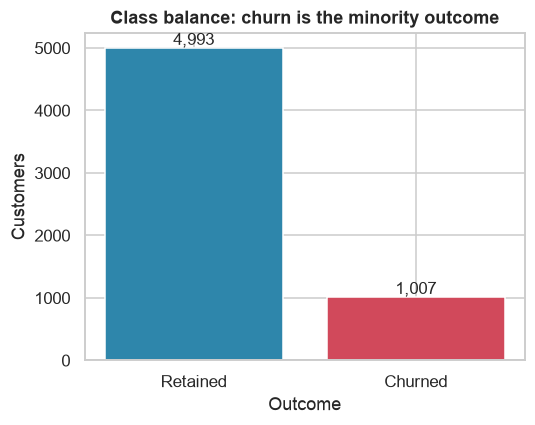

In [5]:
# Visualize the class balance so the imbalance is unmistakable.
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["churn"].map({0: "Retained", 1: "Churned"}).value_counts()
ax.bar(counts.index, counts.values, color=[PALETTE["retain"], PALETTE["churn"]])
ax.set_title("Class balance: churn is the minority outcome")
ax.set_ylabel("Customers"); ax.set_xlabel("Outcome")
for i, v in enumerate(counts.values): ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()

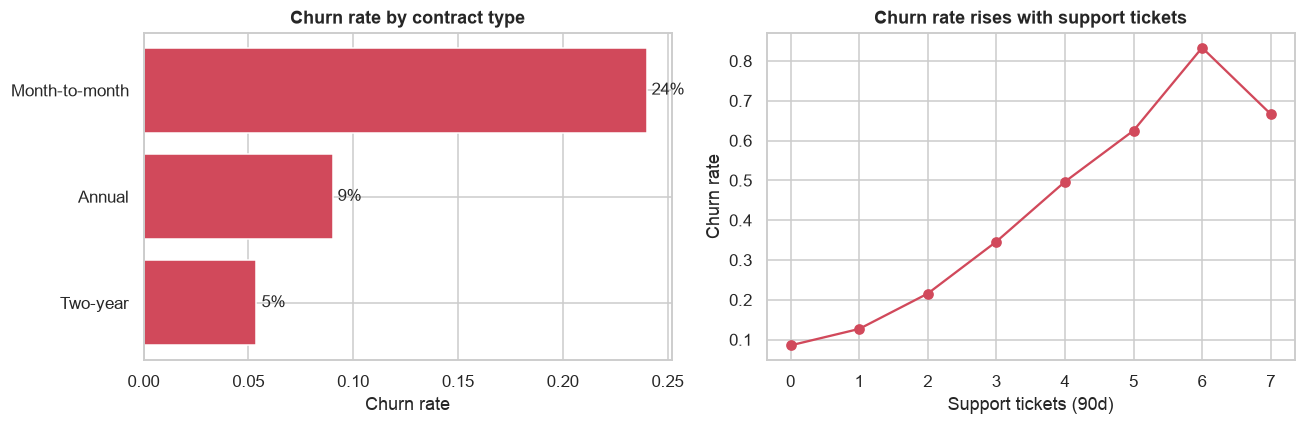

In [6]:
# Churn rate sliced by contract type — a classic, high-signal driver.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_contract = df.groupby("contract_type")["churn"].mean().sort_values()
axes[0].barh(by_contract.index, by_contract.values, color=PALETTE["churn"])
axes[0].set_title("Churn rate by contract type"); axes[0].set_xlabel("Churn rate")
for i, v in enumerate(by_contract.values): axes[0].text(v, i, f" {v:.0%}", va="center")

# Churn rate by support burden (tickets in the last 90 days).
by_tickets = df.groupby("support_tickets_90d")["churn"].mean()
axes[1].plot(by_tickets.index, by_tickets.values, marker="o", color=PALETTE["churn"])
axes[1].set_title("Churn rate rises with support tickets")
axes[1].set_xlabel("Support tickets (90d)"); axes[1].set_ylabel("Churn rate")
plt.tight_layout()

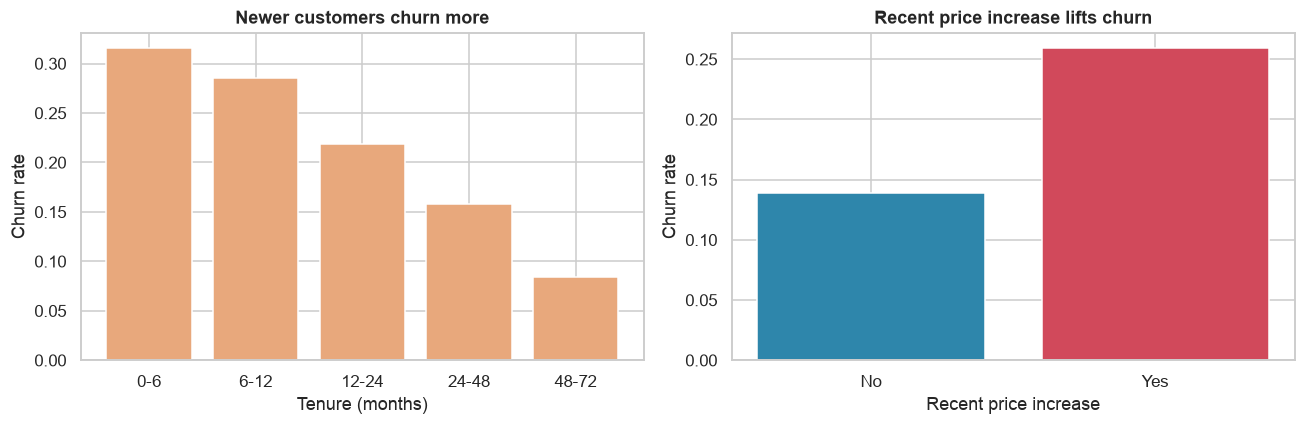

In [7]:
# Churn rate by tenure and by recent price increase — two more strong drivers.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["tenure_bin"] = pd.cut(df["tenure_months"], [0, 6, 12, 24, 48, 72],
                          labels=["0-6", "6-12", "12-24", "24-48", "48-72"])
by_tenure = df.groupby("tenure_bin")["churn"].mean()
axes[0].bar(by_tenure.index.astype(str), by_tenure.values, color=PALETTE["accent"])
axes[0].set_title("Newer customers churn more"); axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Churn rate")

by_price = df.groupby("price_increase_recent")["churn"].mean()
axes[1].bar(["No", "Yes"], by_price.values, color=[PALETTE["retain"], PALETTE["churn"]])
axes[1].set_title("Recent price increase lifts churn"); axes[1].set_xlabel("Recent price increase")
axes[1].set_ylabel("Churn rate")
plt.tight_layout()

### What drives churn in this data, before modeling

Four patterns stand out from simple slices:

1. **Contract type** — month-to-month customers churn far more than annual / two-year.
2. **Support burden** — churn climbs with each additional support ticket.
3. **Tenure** — the first 6–12 months are the riskiest; churn falls with tenure.
4. **Price shocks** — a recent price increase visibly raises churn.

Each of these maps to a retention lever the recommendation layer uses later. Next, a model
that combines them into a per-customer risk score.


## Phase 2 — Feature Engineering & Preprocessing

Preprocessing lives in a scikit-learn `Pipeline` so the same transformations run in
training and serving. The pipeline definition is imported directly from `src/train.py` —
the same code the API uses — so the notebook and production can't drift apart.


In [8]:
# Reuse the production feature lists and pipeline builder (single source of truth).
import sys; sys.path.append("..")
from src.train import NUMERIC_FEATURES, CATEGORICAL_FEATURES, build_pipeline

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["churn"].astype(int)
print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical features")

10 numeric + 3 categorical features


In [9]:
# Stratified split preserves the ~17% churn rate in both train and test.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"train churn={y_train.mean():.1%}  |  test churn={y_test.mean():.1%}")

train churn=16.8%  |  test churn=16.8%


**Class imbalance handling.** With only ~17% positives, I reweight the positive class via XGBoost's `scale_pos_weight` (= #negatives / #positives) rather than
oversampling. Reweighting the gradient is cheaper, introduces no synthetic rows, and
avoids the leakage risks of resampling before cross-validation. The probabilities are then calibrated
(Phase 3) so the reweighting doesn't distort the scores downstream layers rely on.

## Phase 3 — Model Selection, Training & Evaluation

XGBoost is compared against a logistic-regression baseline rather than assumed. Accuracy
is misleading on an imbalanced problem, so candidates are judged on:

- **PR-AUC** — performance on the minority (churn) class
- **ROC-AUC** — overall ranking quality
- **Calibration** — whether the predicted probabilities can be taken at face value
  (they feed the dollar calculations later)
- **Precision at a capacity threshold** — if the team can only call N customers per week,
  how many of those calls land on real churners

### Model comparison: baseline vs. tuned XGBoost


In [10]:
# Reuse the EXACT model-selection code that powers src/train.py.
from src.train import (build_baseline_pipeline, build_pipeline,
                       search_xgb_params, DEFAULT_XGB_PARAMS)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos   # scale_pos_weight = #negatives / #positives

# Candidate 1: a strong linear baseline the tree model has to beat.
baseline = build_baseline_pipeline().fit(X_train, y_train)
# Candidate 2: XGBoost with known-good defaults.
xgb_default = build_pipeline(spw, DEFAULT_XGB_PARAMS).fit(X_train, y_train)

In [11]:
# Candidate 3: XGBoost with light RandomizedSearchCV tuning (PR-AUC scored).
from sklearn.metrics import average_precision_score, roc_auc_score
best_params = search_xgb_params(X_train, y_train, spw, n_iter=20)
xgb_tuned = build_pipeline(spw, best_params).fit(X_train, y_train)

def _scores(m):  # PR-AUC + ROC-AUC on the held-out test set
    p = m.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, p), roc_auc_score(y_test, p)

compare = pd.DataFrame({n: _scores(m) for n, m in {
    "Logistic (baseline)": baseline, "XGBoost (default)": xgb_default,
    "XGBoost (tuned)": xgb_tuned}.items()}, index=["PR-AUC", "ROC-AUC"]).T.round(4)
compare

Search best CV PR-AUC=0.5934  params={'subsample': 0.7, 'reg_lambda': 2.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


,PR-AUC,ROC-AUC
Logistic (baseline),0.5707,0.8479
XGBoost (default),0.5679,0.8357
XGBoost (tuned),0.5709,0.8416


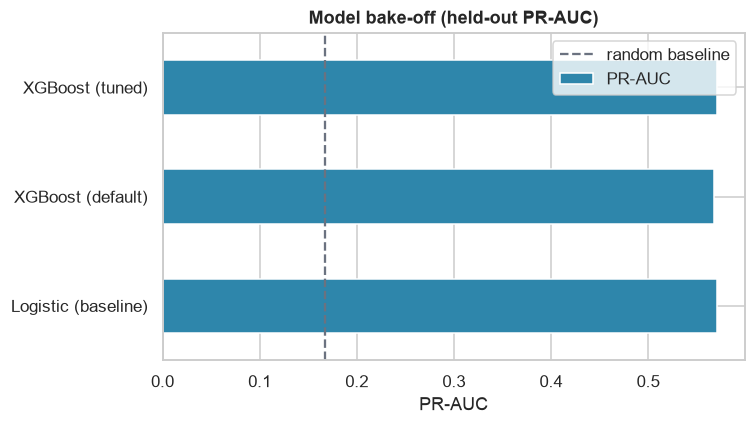

In [12]:
# Visualize the bake-off — tuned XGBoost is the deployed model.
fig, ax = plt.subplots(figsize=(7, 4))
compare["PR-AUC"].plot(kind="barh", ax=ax, color=PALETTE["retain"])
ax.axvline(y_test.mean(), ls="--", color=PALETTE["neutral"], label="random baseline")
ax.set_title("Model bake-off (held-out PR-AUC)"); ax.set_xlabel("PR-AUC")
ax.legend(); plt.tight_layout()

**Caption:** The tuned XGBoost edges out a strong logistic baseline. The margin is
narrow — because much of churn here *is* near-linear — but boosting captures the
interaction effects (e.g., price hikes hurting new customers more) that the linear model
can't. The tuned model is deployed and calibrated next. (If the
baseline had won, the baseline would ship — selection is automatic in `src/train.py`.)

In [13]:
# The winning pipeline, used for all downstream evaluation + explainability.
pipeline = xgb_tuned
proba = pipeline.predict_proba(X_test)[:, 1]   # calibrated P(churn) on held-out data
print("Deployed model: tuned XGBoost. Sample churn probabilities:", np.round(proba[:5], 3))

Deployed model: tuned XGBoost. Sample churn probabilities: [0.309 0.026 0.099 0.43  0.535]


In [14]:
# Headline metrics for an imbalanced problem.
from sklearn.metrics import average_precision_score, roc_auc_score
pr_auc = average_precision_score(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)
print(f"PR-AUC : {pr_auc:.3f}   (baseline = churn rate = {y_test.mean():.3f})")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Lift over baseline (PR): {pr_auc / y_test.mean():.1f}x")

PR-AUC : 0.571   (baseline = churn rate = 0.168)
ROC-AUC: 0.842
Lift over baseline (PR): 3.4x


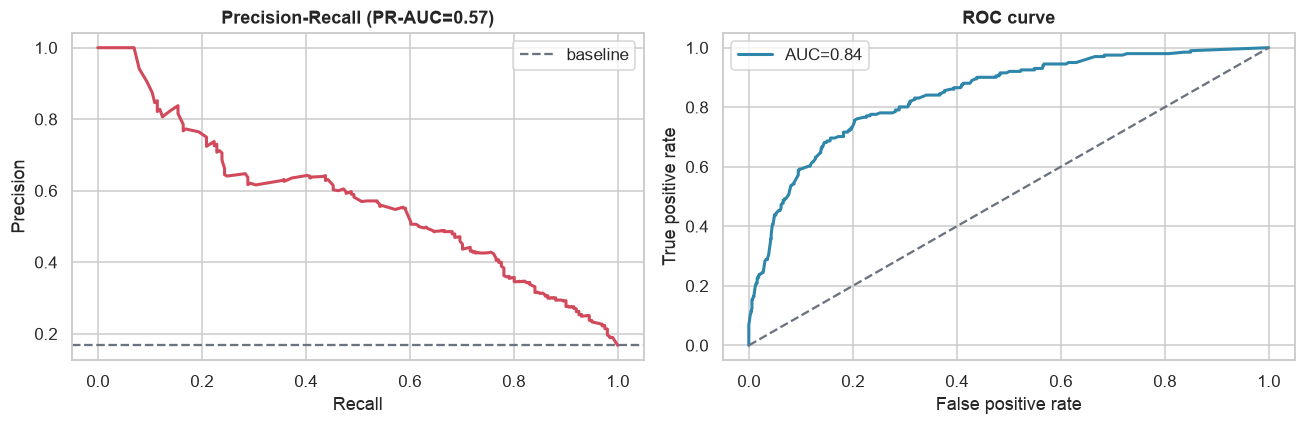

In [15]:
# Precision-Recall and ROC curves side by side.
from sklearn.metrics import precision_recall_curve, roc_curve
prec, rec, _ = precision_recall_curve(y_test, proba)
fpr, tpr, _ = roc_curve(y_test, proba)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rec, prec, color=PALETTE["churn"], lw=2)
axes[0].axhline(y_test.mean(), ls="--", color=PALETTE["neutral"], label="baseline")
axes[0].set_title(f"Precision-Recall (PR-AUC={pr_auc:.2f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].legend()
axes[1].plot(fpr, tpr, color=PALETTE["retain"], lw=2, label=f"AUC={roc_auc:.2f}")
axes[1].plot([0, 1], [0, 1], ls="--", color=PALETTE["neutral"])
axes[1].set_title("ROC curve"); axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate"); axes[1].legend()
plt.tight_layout()

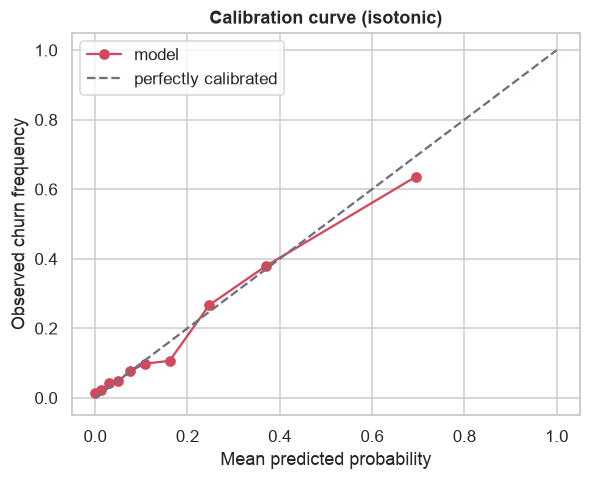

In [16]:
# Calibration curve: do predicted probabilities match observed churn frequency?
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(mean_pred, frac_pos, marker="o", color=PALETTE["churn"], label="model")
ax.plot([0, 1], [0, 1], ls="--", color=PALETTE["neutral"], label="perfectly calibrated")
ax.set_title("Calibration curve (isotonic)")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed churn frequency")
ax.legend(); plt.tight_layout()

**Caption:** Points hug the diagonal: when the model says "30% risk," roughly 30% of
those customers actually churn. Calibration matters here because the economics layer
multiplies these probabilities by dollar values — a miscalibrated score would distort
every downstream budget number.


### Choosing the operating point from team capacity

The threshold isn't a statistical choice — it's an *operational* one. Suppose the retention
team can work the top 15% of the book each cycle: sort customers by risk, draw the line
at that capacity, and read off the precision (how many calls land on real churners)
and recall (share of all churners caught).

In [17]:
# Sweep: as we contact more of the ranked book, how do precision & recall move?
order = np.argsort(proba)[::-1]            # customers from highest to lowest risk
y_sorted = y_test.values[order]
contacted = np.arange(1, len(y_sorted) + 1)
precision_curve = np.cumsum(y_sorted) / contacted
recall_curve = np.cumsum(y_sorted) / y_sorted.sum()

CAPACITY = 0.15                            # team can work the top 15% each cycle
k = int(CAPACITY * len(y_sorted))
print(f"At capacity = top {CAPACITY:.0%} ({k} of {len(y_sorted)} customers):")
print(f"  precision = {precision_curve[k-1]:.0%}  (base rate {y_test.mean():.0%})")
print(f"  recall    = {recall_curve[k-1]:.0%}  of all churners caught")

At capacity = top 15% (180 of 1200 customers):
  precision = 57%  (base rate 17%)
  recall    = 51%  of all churners caught


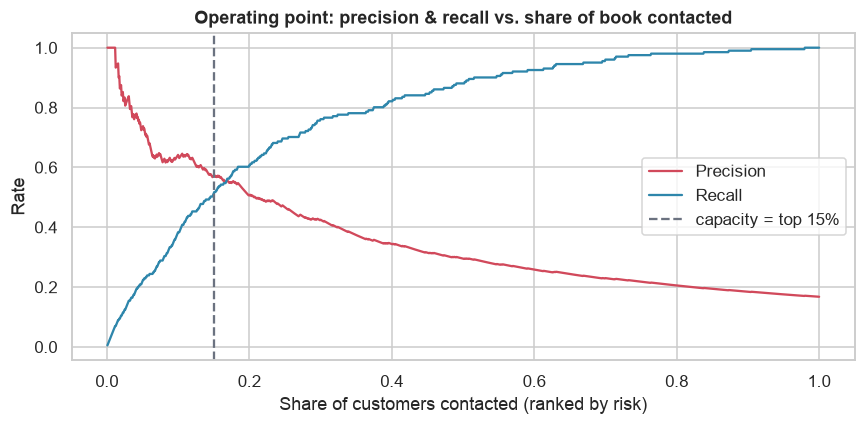

In [18]:
# Plot the precision/recall trade-off vs. how many customers we choose to contact.
frac = contacted / len(y_sorted)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(frac, precision_curve, color=PALETTE["churn"], label="Precision")
ax.plot(frac, recall_curve, color=PALETTE["retain"], label="Recall")
ax.axvline(CAPACITY, ls="--", color=PALETTE["neutral"], label=f"capacity = top {CAPACITY:.0%}")
ax.set_title("Operating point: precision & recall vs. share of book contacted")
ax.set_xlabel("Share of customers contacted (ranked by risk)"); ax.set_ylabel("Rate")
ax.legend(); plt.tight_layout()

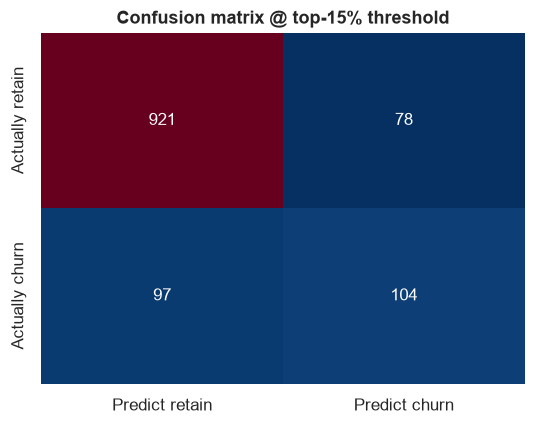

In [19]:
# Confusion matrix at the capacity-based threshold.
from sklearn.metrics import confusion_matrix
cutoff = np.sort(proba)[::-1][k - 1]       # probability at the capacity cut
flagged = proba >= cutoff
cm = confusion_matrix(y_test, flagged.astype(int))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="RdBu_r", cbar=False,
            xticklabels=["Predict retain", "Predict churn"],
            yticklabels=["Actually retain", "Actually churn"], ax=ax)
ax.set_title(f"Confusion matrix @ top-{CAPACITY:.0%} threshold"); plt.tight_layout()

### What the metrics mean for the business

Working the top 15% of accounts by risk catches about half of all churners at several
times the base-rate precision — most calls land on customers who really were about to
leave. The sweep above also shows how the threshold moves with capacity: more headcount
shifts the cutoff right (higher recall), less shifts it left (higher precision). Because
the probabilities are calibrated, risk at any cutoff can be converted directly into
expected revenue at risk.


## Phase 4 — Explainability (SHAP)

A score the team can't interpret is hard to trust and harder to act on. SHAP decomposes
every prediction into per-feature contributions, both globally (what drives churn across
the book) and locally (why this customer was flagged). The local view feeds the
next-best-action layer: the dominant driver picks the intervention.

> SHAP is computed on the underlying XGBoost tree model (calibration only rescales the
> output probability; it doesn't change which features drive the risk ranking).


In [20]:
# Fit a standalone XGBoost on the transformed features for fast exact TreeSHAP.
import shap
from xgboost import XGBClassifier
prep = pipeline.named_steps["prep"]
X_train_t = prep.transform(X_train); X_test_t = prep.transform(X_test)
feat_names = prep.get_feature_names_out()

explainer_model = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    scale_pos_weight=neg / pos, eval_metric="aucpr", random_state=RANDOM_STATE)
explainer_model.fit(X_train_t, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [21]:
# Build a SHAP Explanation object with readable feature names.
X_test_df = pd.DataFrame(X_test_t, columns=feat_names)
explainer = shap.TreeExplainer(explainer_model)
shap_exp = explainer(X_test_df)
print("SHAP values computed for", shap_exp.shape[0], "test customers")

SHAP values computed for 1200 test customers


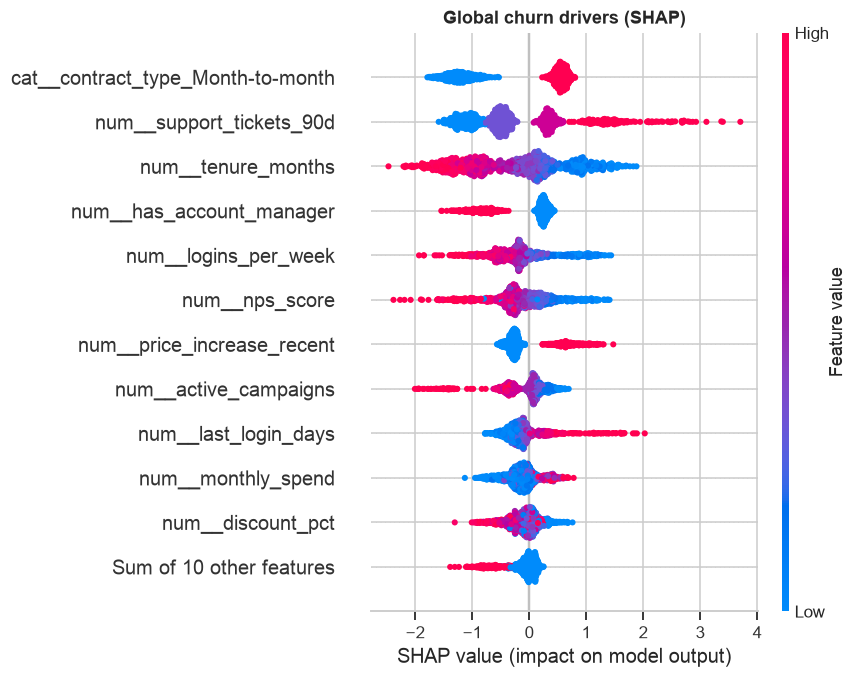

In [22]:
# Global view: SHAP beeswarm — which features move churn risk, and in which direction.
shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.title("Global churn drivers (SHAP)", fontweight="bold"); plt.tight_layout()

**Caption:** Each dot is a customer; features are ranked by overall impact and colored
by feature value. The model recovers the drivers baked into the data — month-to-month
contracts, support tickets, recent price increases, and low engagement push risk up;
tenure, NPS, and an account manager pull it down. (Phase 7 quantifies how completely.)


In [23]:
# Local view: explain the single highest-risk customer with a waterfall plot.
top_idx = int(np.argmax(proba))
shap.plots.waterfall(shap_exp[top_idx], max_display=10, show=False)
plt.title(f"Why customer #{top_idx} was flagged (churn p={proba[top_idx]:.2f})",
          fontweight="bold"); plt.tight_layout()

**Caption:** For this individual, the waterfall shows which factors pushed risk up.
This per-customer attribution is what makes the recommendation specific rather than
generic, and gives the rep a one-sentence reason for the outreach.


### Why explainability matters here

Global SHAP confirms the model learned sensible drivers, which is what stakeholders need
to trust the scores. Local SHAP identifies the lever for each account, which is what the
recommendation layer needs to pick an action. Both uses are structural, not cosmetic:
without the local attributions there would be no principled way to choose between a
discount, a support call, and a re-onboarding push.


## Phase 5 — Next-Best-Action Recommendation Layer

For every high-risk customer, the dominant SHAP driver is mapped through the rules in
`src/recommend.py` to a concrete, costed retention action. The output is a ranked
worklist with an action and rationale per row.


In [24]:
# Score each test customer's SHAP drivers, recommend an action, and price it out.
from src.recommend import recommend_from_shap
from src.economics import expected_value
records = X_test.reset_index(drop=True)
rows = []
for i in range(len(records)):
    feats = records.iloc[i].to_dict()
    shap_dict = dict(zip(feat_names, shap_exp.values[i]))   # per-feature contribution
    rec = recommend_from_shap(proba[i], feats, shap_dict)
    ev = expected_value(proba[i], feats["monthly_spend"], rec.action)   # dollars
    rows.append({"churn_probability": round(float(proba[i]), 3),
                 "top_risk_driver": rec.top_driver, "recommended_action": rec.action,
                 "risk_tier": rec.risk_tier, "monthly_spend": round(feats["monthly_spend"]),
                 "value_at_risk": ev.value_at_risk, "net_value": ev.net_value})
reco_df = pd.DataFrame(rows)

In [25]:
# The retention worklist: highest-risk customers first, with the action for each.
worklist = reco_df.sort_values("churn_probability", ascending=False).head(15).reset_index(drop=True)
worklist.index.name = "rank"
worklist

,churn_probability,top_risk_driver,recommended_action,risk_tier,monthly_spend,value_at_risk,net_value
rank,,,,,,,
0,1.000,High support burden,Proactive support call from a senior rep,High,1747,14670.85,3587.71
1,1.000,Early-tenure risk,Onboarding / success outreach,High,1031,8659.06,1248.86
2,1.000,Early-tenure risk,Onboarding / success outreach,High,941,7900.28,1135.04
3,1.000,Early-tenure risk,Onboarding / success outreach,High,523,4389.25,608.39
4,1.000,Early-tenure risk,Onboarding / success outreach,High,2332,19588.63,2888.29
5,1.000,Low engagement,Re-engagement / onboarding outreach,High,87,734.33,106.87
6,1.000,Early-tenure risk,Onboarding / success outreach,High,125,1051.43,107.71
7,1.000,High support burden,Proactive support call from a senior rep,High,2275,19109.41,4697.35
8,1.000,Early-tenure risk,Onboarding / success outreach,High,1211,10176.01,1476.40


In [26]:
# How retention effort would be distributed across recommended actions (high+medium risk).
actionable = reco_df[reco_df["risk_tier"].isin(["High", "Medium"])]
action_counts = actionable["recommended_action"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(action_counts.index[::-1], action_counts.values[::-1], color=PALETTE["retain"])
ax.set_title("Recommended actions across at-risk customers")
ax.set_xlabel("Number of customers"); plt.tight_layout()

### From prediction to action

Each at-risk account gets a specific, explainable action: a price-shocked customer gets
a loyalty discount, a disengaged one gets re-onboarding, a high-ticket account gets a
proactive support call. The team works a prioritized list with reasons attached instead
of a flat risk score.


## Phase 6 — From Risk to Dollars: Expected-Value Prioritization

Probability answers who is likely to leave; the business also needs to know who is worth
saving and for how much. The economics layer (`src/economics.py`) converts each prediction
into:

- **value at risk** = P(churn) × the customer's margin value over a 12-month horizon
- **expected value saved** = value at risk × the action's assumed retention lift
- **net value** = expected value saved − the action's cost

Ranking by net value instead of probability changes who the team calls first, and how much
the program returns.

> The per-action cost/lift numbers are documented assumptions; in practice each would be
> estimated from a holdout experiment before the dollar figures are trusted.


In [27]:
# Compare two prioritization strategies on the same retention-team budget.
BUDGET = 150   # the team can work 150 accounts this cycle
by_prob = reco_df.sort_values("churn_probability", ascending=False).head(BUDGET)
by_value = reco_df.sort_values("net_value", ascending=False).head(BUDGET)
print(f"Targeting the top {BUDGET} accounts by each strategy:")
print(f"  by churn probability -> expected net value captured = ${by_prob['net_value'].clip(lower=0).sum():,.0f}")
print(f"  by expected net value -> expected net value captured = ${by_value['net_value'].clip(lower=0).sum():,.0f}")

Targeting the top 150 accounts by each strategy:
  by churn probability -> expected net value captured = $93,584
  by expected net value -> expected net value captured = $138,402


In [28]:
# Visualize the uplift from value-based targeting at the same budget.
totals = {"By churn probability": by_prob["net_value"].clip(lower=0).sum(),
          "By expected net value": by_value["net_value"].clip(lower=0).sum()}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(totals.keys(), totals.values(), color=[PALETTE["neutral"], PALETTE["retain"]])
ax.set_title(f"Expected net value captured at a {BUDGET}-account budget")
ax.set_ylabel("Expected net value ($)")
for i, v in enumerate(totals.values()): ax.text(i, v, f"${v:,.0f}", ha="center", va="bottom")
plt.tight_layout()

In [29]:
# The value-ranked worklist the team actually works — dollars front and center.
cols = ["churn_probability", "risk_tier", "monthly_spend", "top_risk_driver",
        "recommended_action", "value_at_risk", "net_value"]
worklist_by_value = by_value[cols].head(15).reset_index(drop=True)
worklist_by_value.index.name = "rank"
worklist_by_value

,churn_probability,risk_tier,monthly_spend,top_risk_driver,recommended_action,value_at_risk,net_value
rank,,,,,,,
0,1.000,High,2275,High support burden,Proactive support call from a senior rep,19109.41,4697.35
1,1.000,High,1747,High support burden,Proactive support call from a senior rep,14670.85,3587.71
2,0.636,High,2310,Low satisfaction (NPS),Executive check-in to rebuild trust,12345.87,3503.76
3,0.813,High,2536,Low engagement,Re-engagement / onboarding outreach,17317.87,3423.57
4,1.000,High,2733,Early-tenure risk,Onboarding / success outreach,22958.12,3393.72
5,0.574,High,3423,Low engagement,Re-engagement / onboarding outreach,16501.76,3260.35
6,0.430,Medium,3292,High support burden,Proactive support call from a senior rep,11885.34,2891.34
7,1.000,High,2332,Early-tenure risk,Onboarding / success outreach,19588.63,2888.29
8,0.286,Medium,3400,Month-to-month contract,Incentivize an annual contract upgrade,8172.50,2740.38


### Value ranking changes who gets called first

Same model, same budget — but targeting by expected net value directs effort toward
accounts where intervention recovers the most margin per dollar. A near-certain-to-churn
\$120/mo account can be worth less to save than a moderate-risk \$2,400/mo one; the
dollar layer makes that trade-off explicit.

The pipeline trained here is the one that gets served: it is serialized to
`models/churn_model.joblib`, and `POST /predict` in `src/api.py` returns the calibrated
probability, the recommended action, and these same expected-value economics.


## Phase 7 — Stress-Testing the Analysis

The results so far look clean, so this section tries to break them. Two questions:

1. **Model recovery.** Because the data is synthetic, the true churn-generating process
   is known exactly, so I can measure how close the model gets to the theoretical ceiling
   and check which of the baked-in effects it actually recovered — and which it missed.
2. **Economics sensitivity.** The dollar-ranked worklist depends on assumed action lifts
   and a 70% gross margin. If those assumptions are wrong, does the "rank by dollars"
   conclusion survive?


In [30]:
# Reconstruct the true (noiseless) churn log-odds from the generator's formula.
# This is the oracle: the best any model could do on these features, since the
# remaining gap to the labels is irreducible noise + Bernoulli sampling.
def true_log_odds(d):
    is_m2m = (d["contract_type"] == "Month-to-month").values
    contract = np.where(is_m2m, 1.1,
                        np.where(d["contract_type"].values == "Annual", -0.4, -1.0))
    return (
        -1.4
        - 0.030 * d["tenure_months"].values
        + 0.045 * d["last_login_days"].values
        - 0.12 * d["logins_per_week"].values
        + 0.55 * d["support_tickets_90d"].values
        + 0.9 * d["price_increase_recent"].values
        - 0.020 * d["discount_pct"].values
        - 0.8 * d["has_account_manager"].values
        - 0.012 * d["nps_score"].values
        + 0.0002 * d["monthly_spend"].values
        - 0.20 * d["active_campaigns"].values
        + contract
        + 0.07 * d["support_tickets_90d"].values ** 2
        + 1.3 * d["price_increase_recent"].values * (d["tenure_months"].values < 12)
        + 0.9 * is_m2m * (d["logins_per_week"].values < 2)
        + 0.8 * (d["last_login_days"].values > 30)
        - 0.6 * (d["tenure_months"].values > 36) * d["has_account_manager"].values
    )

oracle_proba = 1 / (1 + np.exp(-true_log_odds(X_test)))

print("How close is the model to the theoretical ceiling? (held-out test set)")
print(f"  oracle  ROC-AUC = {roc_auc_score(y_test, oracle_proba):.3f}   "
      f"PR-AUC = {average_precision_score(y_test, oracle_proba):.3f}")
print(f"  model   ROC-AUC = {roc_auc_score(y_test, proba):.3f}   "
      f"PR-AUC = {average_precision_score(y_test, proba):.3f}")
print(f"  corr(model prob, true prob) = {np.corrcoef(proba, oracle_proba)[0, 1]:.3f}")
print(f"  mean |model prob - true prob| = {np.abs(proba - oracle_proba).mean():.3f}")


How close is the model to the theoretical ceiling? (held-out test set)
  oracle  ROC-AUC = 0.853   PR-AUC = 0.585
  model   ROC-AUC = 0.842   PR-AUC = 0.571
  corr(model prob, true prob) = 0.942
  mean |model prob - true prob| = 0.042


In [31]:
# Where do model and oracle disagree the most? Look at the residual structure.
resid = proba - oracle_proba
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(oracle_proba, proba, s=6, alpha=0.3, color=PALETTE["retain"])
axes[0].plot([0, 1], [0, 1], color=PALETTE["neutral"], lw=1, ls="--")
axes[0].set_xlabel("True P(churn) from the generator")
axes[0].set_ylabel("Model P(churn)")
axes[0].set_title("Model vs oracle probability")

# Group the largest over/under-estimates by their dominant segment.
seg = pd.DataFrame({
    "resid": resid,
    "m2m": (X_test["contract_type"] == "Month-to-month").values,
    "tenure_lt_12": (X_test["tenure_months"] < 12).values,
    "price_up": X_test["price_increase_recent"].values.astype(bool),
    "managed_veteran": ((X_test["tenure_months"] > 36)
                        & (X_test["has_account_manager"] == 1)).values,
    "dark_30d": (X_test["last_login_days"] > 30).values,
})
by_seg = (seg.melt(id_vars="resid", var_name="segment", value_name="in_seg")
             .query("in_seg").groupby("segment")["resid"]
             .agg(["mean", "count"]).sort_values("mean"))
axes[1].barh(by_seg.index, by_seg["mean"],
             color=np.where(by_seg["mean"] > 0, PALETTE["churn"], PALETTE["retain"]))
axes[1].axvline(0, color=PALETTE["neutral"], lw=1)
axes[1].set_xlabel("Mean (model prob - true prob)")
axes[1].set_title("Average probability error by segment")
plt.tight_layout()
by_seg.round(3)


,mean,count
segment,,
dark_30d,-0.166,17
price_up,-0.010,289
tenure_lt_12,-0.000,165
managed_veteran,0.009,177
m2m,0.010,664


In [32]:
# Interaction recovery: the generator contains two interactions a linear model
# can't represent. Test whether the model found them with counterfactual flips.
def avg_effect_of_flip(col, mask):
    """Average change in P(churn) when `col` flips 0 -> 1, within `mask` rows."""
    base = X_test[mask].copy(); base[col] = 0
    flip = base.copy(); flip[col] = 1
    model_delta = (pipeline.predict_proba(flip)[:, 1]
                   - pipeline.predict_proba(base)[:, 1]).mean()
    true_delta = (1 / (1 + np.exp(-true_log_odds(flip)))
                  - 1 / (1 + np.exp(-true_log_odds(base)))).mean()
    return model_delta, true_delta

checks = {
    "Price increase, tenure < 12m": avg_effect_of_flip(
        "price_increase_recent", X_test["tenure_months"] < 12),
    "Price increase, tenure >= 12m": avg_effect_of_flip(
        "price_increase_recent", X_test["tenure_months"] >= 12),
    "Account manager, tenure > 36m": avg_effect_of_flip(
        "has_account_manager", X_test["tenure_months"] > 36),
    "Account manager, tenure <= 36m": avg_effect_of_flip(
        "has_account_manager", X_test["tenure_months"] <= 36),
}
inter = pd.DataFrame(checks, index=["model", "true"]).T.round(3)

x = np.arange(len(inter)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w / 2, inter["true"], w, label="True effect (generator)", color=PALETTE["neutral"])
ax.bar(x + w / 2, inter["model"], w, label="Model-implied effect", color=PALETTE["retain"])
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(inter.index, rotation=15, ha="right")
ax.set_ylabel("Avg change in P(churn) when flag flips 0 -> 1")
ax.set_title("Did the model recover the baked-in interactions?")
ax.legend()
plt.tight_layout()
inter


,model,true
"Price increase, tenure < 12m",0.261,0.348
"Price increase, tenure >= 12m",0.075,0.085
"Account manager, tenure > 36m",-0.071,-0.077
"Account manager, tenure <= 36m",-0.110,-0.090


**What the recovery check shows.** The model captures most of the available signal —
ROC-AUC 0.842 against an oracle ceiling of 0.853, with a 0.94 correlation between model and
true probabilities. It clearly recovers the *price increase x low tenure* interaction: the
counterfactual price-increase effect on young accounts (+0.26) is about 3.5x the effect on
older ones, in the same direction as the generator's truth (+0.35), though attenuated. The
failures are just as informative: the segment residuals show the model most underestimates
risk for customers past the 30-day "going dark" threshold (only ~17 such customers in the
test set, so the step effect is hard to learn), and the account-manager check shows the model
applies roughly the same effect to long- and short-tenure accounts instead of fully separating
the interaction. Both are the expected cost of learning from 4,800 noisy rows — gaps that more
data would close before more hyperparameter tuning would.


In [33]:
# Economics sensitivity: the worklist conclusion depends on assumed lifts and margin.
# Re-run the "value-ranked vs probability-ranked" comparison across a grid of both.
from src.economics import ACTION_ECONOMICS, HORIZON_MONTHS

spend = reco_df["monthly_spend"].values.astype(float)
p_churn = reco_df["churn_probability"].values
costs = reco_df["recommended_action"].map(
    lambda a: ACTION_ECONOMICS.get(a, {"cost": 50})["cost"]).values.astype(float)
lifts = reco_df["recommended_action"].map(
    lambda a: ACTION_ECONOMICS.get(a, {"lift": 0.15})["lift"]).values

def captured(net, order_by):
    idx = np.argsort(order_by)[::-1][:BUDGET]
    return np.clip(net[idx], 0, None).sum()

lift_mults = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
margins = [0.5, 0.6, 0.7, 0.8, 0.9]
rows = []
for m in margins:
    for lm in lift_mults:
        net = p_churn * (lifts * lm) * (spend * HORIZON_MONTHS * m) - costs
        rows.append({"margin": m, "lift_mult": lm,
                     "advantage": captured(net, net) / captured(net, p_churn) - 1})
sens = pd.DataFrame(rows).pivot(index="margin", columns="lift_mult", values="advantage")

fig, ax = plt.subplots(figsize=(8, 4))
for m in margins:
    ax.plot(lift_mults, sens.loc[m] * 100, marker="o", label=f"margin {m:.0%}",
            color=plt.cm.Blues(0.3 + 0.6 * (m - 0.5) / 0.4))
ax.axhline(0, color=PALETTE["neutral"], lw=1)
ax.set_xlabel("Multiplier on ALL assumed action lifts")
ax.set_ylabel("Extra net value captured vs\nprobability ranking (%)")
ax.set_title(f"Value-ranking advantage across assumption grid (budget = {BUDGET} accounts)")
ax.legend(fontsize=9)
plt.tight_layout()
(sens * 100).round(1)


lift_mult,0.25,0.50,0.75,1.00,1.25,1.50
margin,,,,,,
0.5,47.0,51.2,50.3,49.1,48.3,47.7
0.6,48.5,51.2,49.6,48.4,47.7,47.3
0.7,49.6,50.6,48.9,47.9,47.3,46.9
0.8,50.5,50.0,48.4,47.5,47.0,46.7
0.9,51.0,49.6,48.0,47.3,46.8,46.5


In [34]:
# Breakeven lifts: how wrong could each lift assumption be before acting loses money?
# For each account the team would actually work, the breakeven lift is
# cost / (P(churn) x customer value). Compare the median breakeven to the assumption.
cust_value = spend * HORIZON_MONTHS * 0.70
breakeven = costs / np.clip(p_churn * cust_value, 1e-9, None)
worked = np.argsort(p_churn * lifts * cust_value - costs)[::-1][:BUDGET]

be = (pd.DataFrame({"action": reco_df["recommended_action"].values[worked],
                    "assumed_lift": lifts[worked],
                    "breakeven_lift": breakeven[worked]})
        .groupby("action")
        .agg(n=("assumed_lift", "size"), assumed_lift=("assumed_lift", "first"),
             median_breakeven=("breakeven_lift", "median"))
        .sort_values("n", ascending=False))
be["safety_factor"] = (be["assumed_lift"] / be["median_breakeven"]).round(1)
be.round(3)


,n,assumed_lift,median_breakeven,safety_factor
action,,,,
Proactive support call from a senior rep,51,0.25,0.027,9.3
Onboarding / success outreach,36,0.15,0.012,12.4
Re-engagement / onboarding outreach,23,0.20,0.015,13.2
Incentivize an annual contract upgrade,18,0.35,0.062,5.6
Offer a loyalty discount / lock-in pricing,13,0.30,0.070,4.3
Executive check-in to rebuild trust,9,0.30,0.091,3.3


**What the sensitivity analysis shows.** The value-ranked worklist beats probability
ranking across the entire assumption grid — the advantage shrinks as lifts get small (there's
less recoverable value to reorder) but never flips negative, so the *ranking policy* doesn't
depend on the assumptions being right. The breakeven table makes the margin of error concrete:
for the accounts the team would actually work, assumed lifts sit well above their breakeven
levels, meaning the real lifts could come in at a fraction of the assumed ones and the worked
accounts would still be positive expected value. The fragile part is not the ranking but the
*absolute* dollar figures — those genuinely require the holdout experiments flagged in the
caveats before anyone budgets against them.
